In [13]:
dataset_folder = '/mnt/Data1/Nick/transcription_pipeline/'

embryo_datasets = {
    # 22C embryos Var2, 0.230 um/pixel
    '001': [
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo01',
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo02',
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo03',
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo04',
    ],

    # 22C embryos PWM, 0.230 um/pixel
    '003': [
        'test_data/NSPARC/2025-05-27/MCP-mSG_His-RFP_RBS(003)_embryo02',
        'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo01',
        'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo02',
    ],

    'test': [
        'test_data/NSPARC/2025-06-16/MCP-mSG_His-RFP_RBS(001)_embryo02',
        'test_data/NSPARC/2025-06-16/MCP-mEGFP_His-RFP_RBS(001)_embryo01',
    ]
}

print(embryo_datasets['001'][0])

test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo01


Dataset Path: /mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-06-16/MCP-mEGFP_His-RFP_RBS(001)_embryo01


/tmp/ipykernel_2535856/1531352443.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected_spots["t_min"] = detected_spots["t_s"] / 60
/tmp/ipykernel_2535856/1531352443.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected_spots["t_bin"] = detected_spots["t_min"].astype(int)


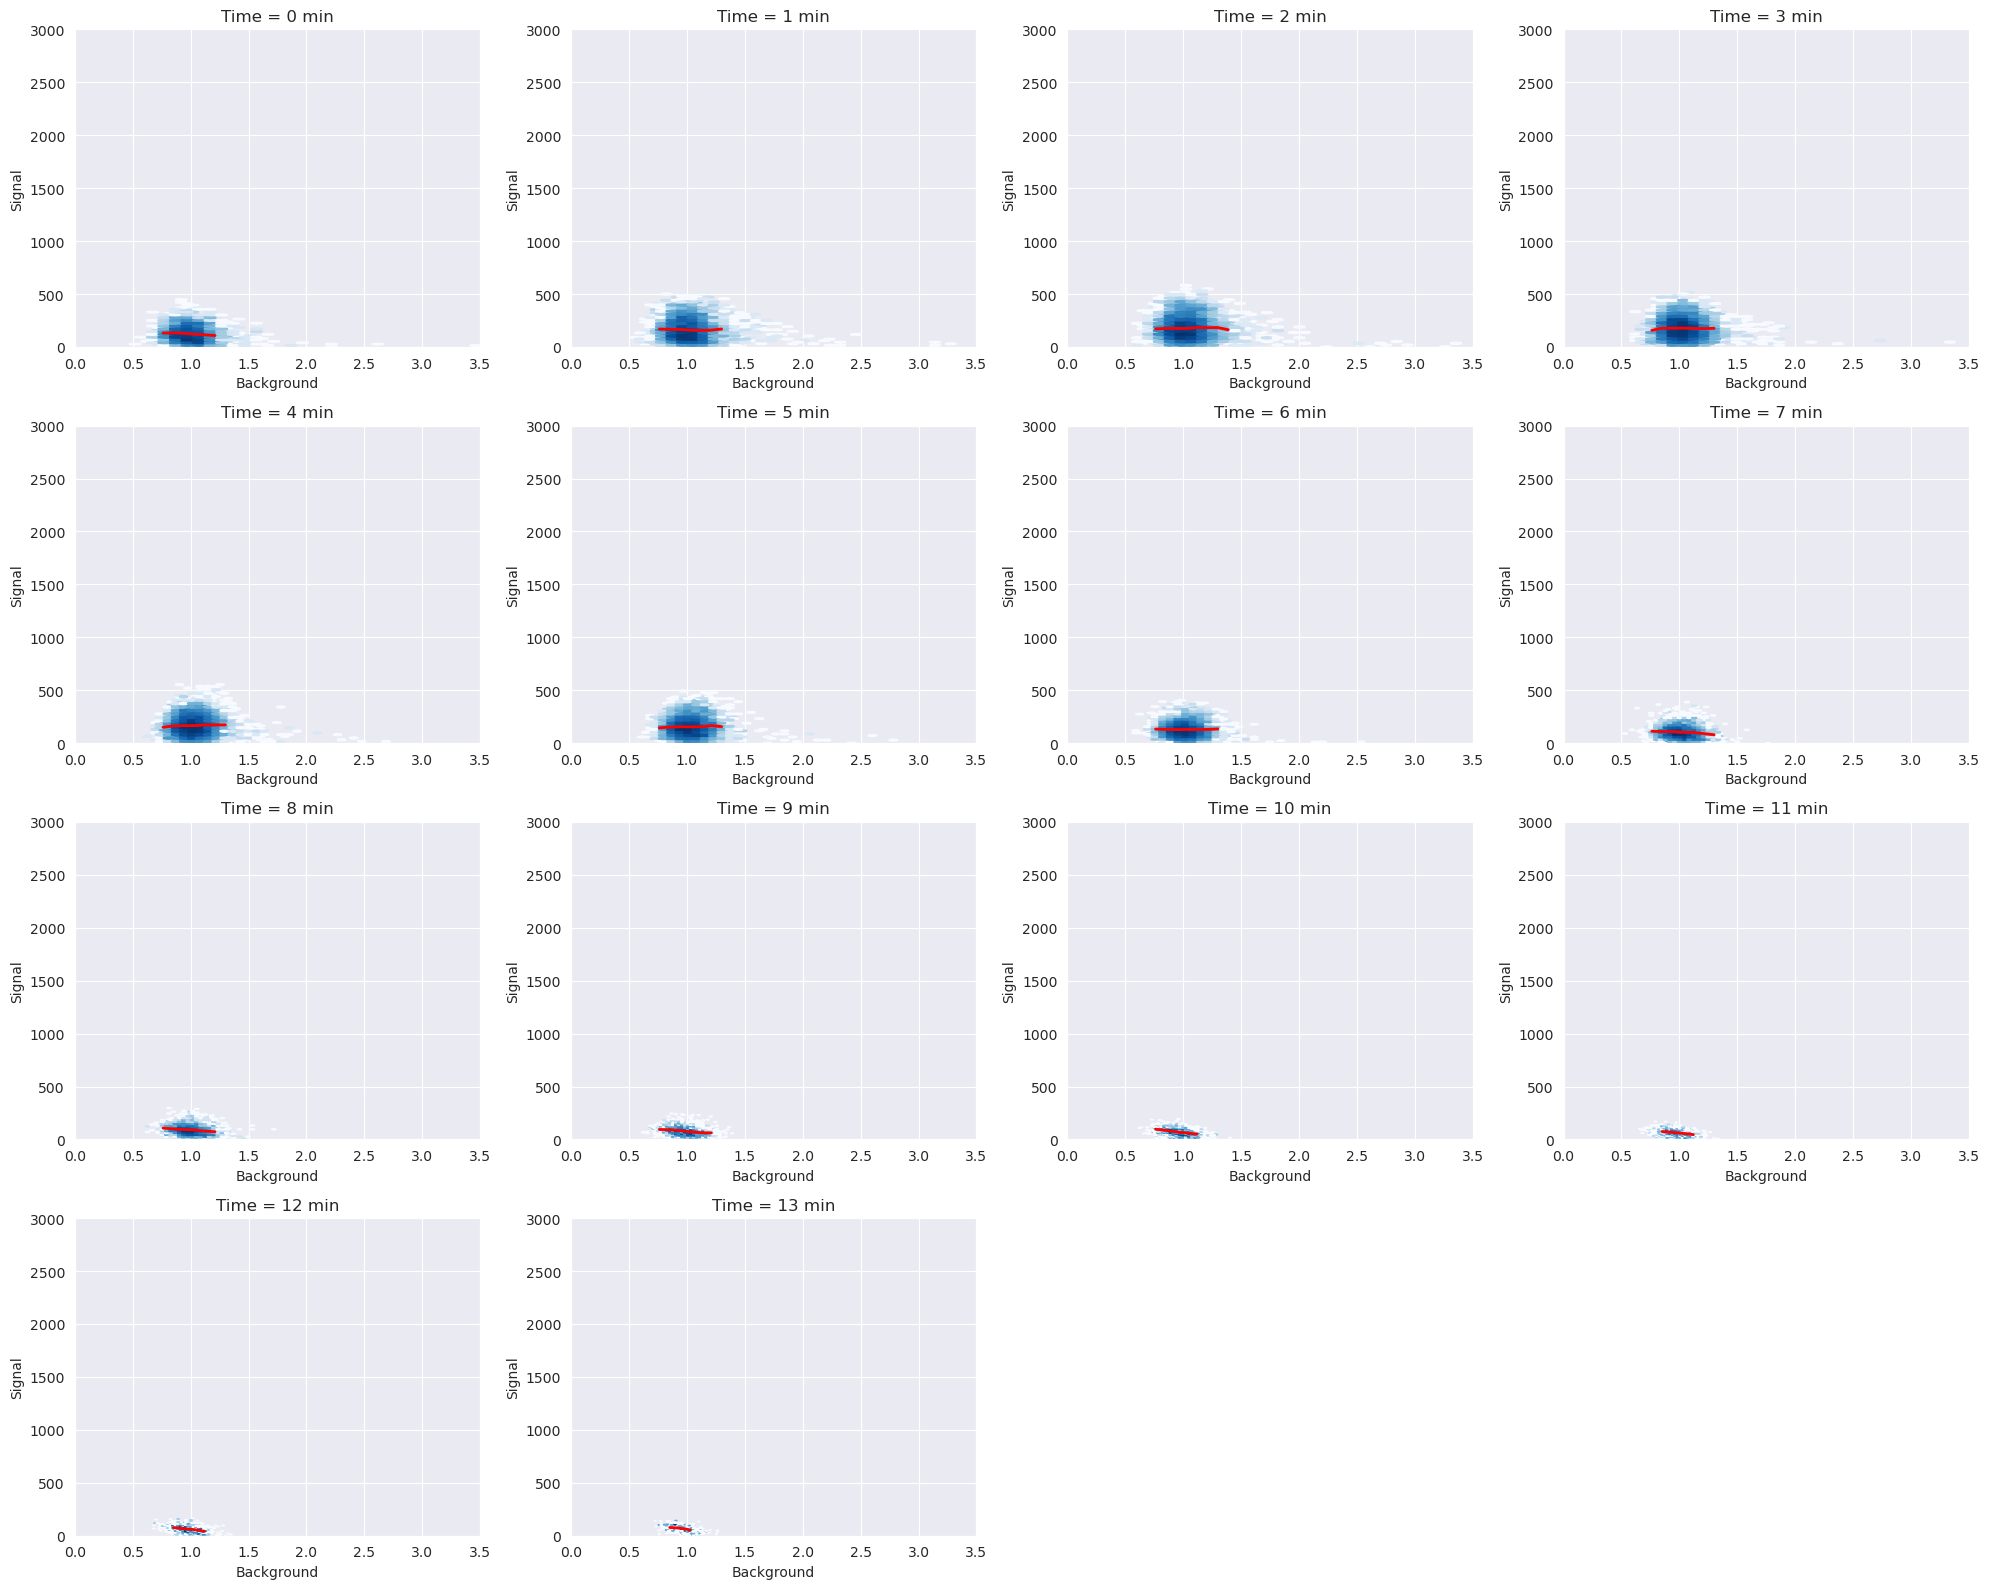

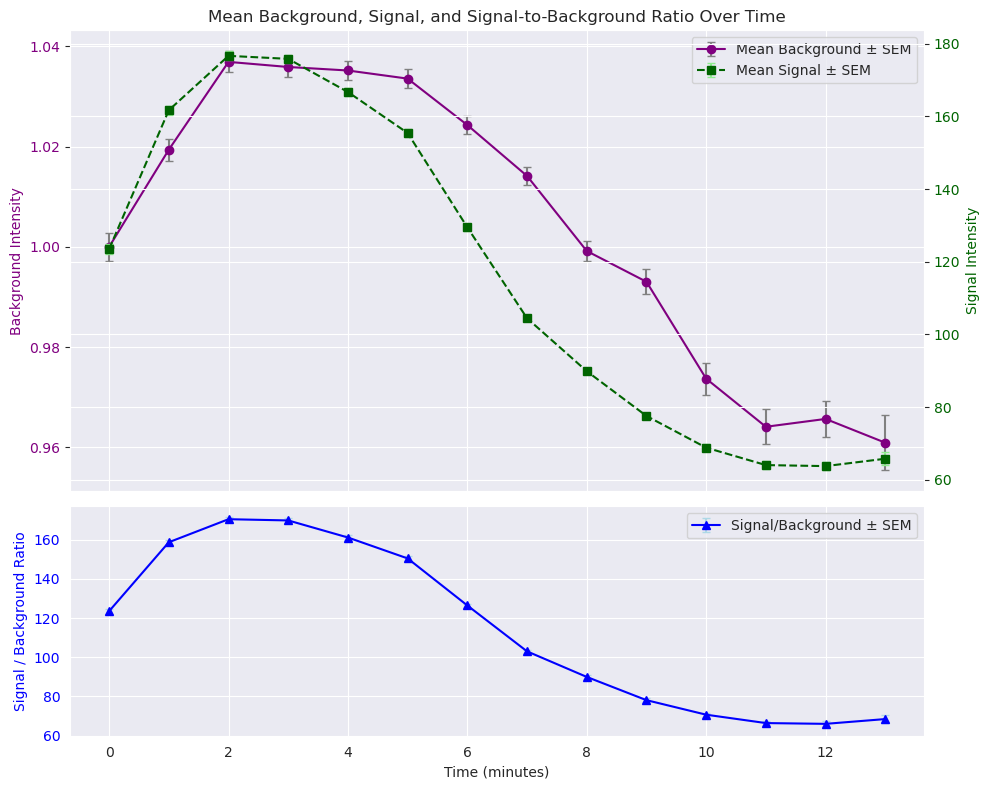

In [16]:
import os
from transcription_pipeline.RateExtraction import FitAndAverage
from transcription_pipeline import spot_pipeline
# from transcription_pipeline import nuclear_pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

# Parameters
nc14_start_frame = 0
min_frames = 40
num_bins = 40

results = []

embryo_id = embryo_datasets['test'][1]
test_dataset_name = os.path.join(dataset_folder, embryo_id)
print('Dataset Path: ' + test_dataset_name)

# --- Load Spot Data ---
spot_tracking = spot_pipeline.Spot()
spot_tracking.read_results(name_folder=test_dataset_name)

spot_df = spot_tracking.spot_dataframe
detected_spots = spot_df[spot_df["particle"] != 0]

# Convert time (t_s) from seconds to minutes
detected_spots["t_min"] = detected_spots["t_s"] / 60
detected_spots["t_bin"] = detected_spots["t_min"].astype(int)

# Group by minute
grouped = detected_spots.groupby("t_bin")

# Plotting
num_plots = len(grouped)
cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

min_points = 50
bins = np.linspace(0, 2.6, 30)  # consistent background range across all plots
bin_centers = (bins[:-1] + bins[1:]) / 2

for i, (minute, group) in enumerate(grouped):
    signal = np.array(group["intensity_from_neighborhood"])
    background = np.array(group["background_intensity_from_neighborhood"])
    digitized = np.digitize(background, bins)

    mean_signal = []
    std_signal = []
    valid_centers = []

    for j in range(1, len(bins)):
        bin_points = signal[digitized == j]
        if len(bin_points) >= min_points:
            mean_signal.append(np.mean(bin_points))
            std_signal.append(np.std(bin_points) / np.sqrt(len(bin_points)))
            valid_centers.append(bin_centers[j - 1])

    ax = axes[i]
    hb = ax.hexbin(background, signal, gridsize=30, cmap='Blues', bins='log')
    ax.plot(valid_centers, mean_signal, 'r-', linewidth=2)
    ax.fill_between(valid_centers,
                    np.array(mean_signal) - np.array(std_signal),
                    np.array(mean_signal) + np.array(std_signal),
                    color='red', alpha=0.2)
    ax.set_xlim(0, 3.5)
    ax.set_ylim(0,3000)
    ax.set_title(f'Time = {minute} min')
    ax.set_xlabel('Background')
    ax.set_ylabel('Signal')

# Hide any extra subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# --- Compute stats for signal and background over time ---
avg_background = grouped["background_intensity_from_neighborhood"].mean()
std_background = grouped["background_intensity_from_neighborhood"].std()

avg_signal = grouped["intensity_from_neighborhood"].mean()
std_signal = grouped["intensity_from_neighborhood"].std()

count_per_bin = grouped.size()
sem_background = std_background / np.sqrt(count_per_bin)
sem_signal = std_signal / np.sqrt(count_per_bin)

# --- Compute signal-to-background ratio and its SEM ---
ratio = avg_signal / avg_background
sem_ratio = ratio * np.sqrt((sem_signal / avg_signal)**2 + (sem_background / avg_background)**2)

# --- Plot background and signal with shared gridlines ---
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])

# --- Top plot: Background and Signal ---
# Background (primary axis)
ax1 = ax_top
ax2 = ax1.twinx()

ax1.errorbar(avg_background.index, avg_background, yerr=sem_background,
             fmt='o-', color='purple', ecolor='gray', capsize=3, label='Mean Background ± SEM')
ax1.set_ylabel('Background Intensity', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True)

# Signal (secondary axis)
ax2.errorbar(avg_signal.index, avg_signal, yerr=sem_signal,
             fmt='s--', color='darkgreen', ecolor='lightgreen', capsize=3, label='Mean Signal ± SEM')
ax2.set_ylabel('Signal Intensity', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.set_facecolor('none')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Title
ax1.set_title('Mean Background, Signal, and Signal-to-Background Ratio Over Time')

# --- Bottom plot: Ratio ---
ax_bot.errorbar(ratio.index, ratio, yerr=sem_ratio,
                fmt='^-', color='blue', ecolor='lightblue', capsize=3, label='Signal/Background ± SEM')
ax_bot.set_xlabel('Time (minutes)')
ax_bot.set_ylabel('Signal / Background Ratio', color='blue')
ax_bot.tick_params(axis='y', labelcolor='blue')
ax_bot.grid(True)
ax_bot.legend(loc='upper right')

# Final layout
fig.tight_layout()
plt.show()





In [3]:
detected_spots

,label,z_um,y_um,x_um,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,include_spot_by_sigma,trackpy_id,include_spot_by_track,particle,include_spot_by_retrack,z,y,x,t_min,t_bin
0,27,2.619978,12.436208,190.249935,0,3.107212,1,"[[[0, 1, 1, 2, 2, 0, 0, 0, 0], [2, 2, 2, 0, 1,...","[0, 2, 49, 822]","[[0.003915196569256724, -3.2359201360522686e-0...",...,True,1118,True,683,True,5.239957,54.028659,826.534008,0.051787,0
1,32,2.480970,20.239473,186.755735,0,3.107212,1,"[[[0, 1, 1, 0, 1, 0, 0, 1, 1], [0, 1, 1, 0, 2,...","[0, 2, 83, 806]","[[0.004149458491770658, 1.782435559787482e-07,...",...,True,1176,True,707,True,4.961939,87.929662,811.353579,0.051787,0
2,33,2.830395,24.728057,209.472193,0,3.281253,1,"[[[1, 2, 0, 1, 2, 1, 1, 0, 1], [2, 1, 0, 0, 0,...","[0, 3, 103, 905]","[[0.012608944550878576, -1.3033769905390632e-0...",...,True,978,True,589,True,5.660790,107.430154,910.044416,0.054688,0
3,34,3.291259,34.861045,142.966950,0,3.281253,1,"[[[0, 0, 0, 1, 0, 0, 2, 1, 1], [0, 0, 1, 1, 2,...","[0, 3, 146, 616]","[[0.024593739512373834, -3.6051926064586947e-0...",...,True,985,True,20,True,6.582518,151.452556,621.114776,0.054688,0
4,35,2.574139,50.833642,116.368378,0,3.107212,1,"[[[0, 1, 0, 0, 1, 2, 1, 3, 1], [0, 0, 0, 1, 1,...","[0, 2, 216, 501]","[[0.04155181197697648, 1.4264584172664135e-06,...",...,True,887,True,439,True,5.148277,220.844931,505.558234,0.051787,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70722,184,7.218926,54.395439,192.223338,398,810.024160,400,"[[[1, 1, 1, 0, 0, 1, 1, 0, 1], [0, 0, 1, 0, 1,...","[14, 11, 231, 830]","[[0.012745258934762574, -2.7615149105037956e-0...",...,True,100,True,100,True,14.437852,236.319029,835.107385,13.500403,13
70724,188,7.433695,26.058836,229.503329,398,810.198213,400,"[[[0, 0, 2, 1, 3, 1, 1, 1, 1], [0, 1, 1, 2, 2,...","[14, 12, 108, 992]","[[0.008979900498852288, -2.4575668782327716e-0...",...,True,101,True,101,True,14.867390,113.211678,997.068965,13.503304,13
70725,191,8.333320,44.572140,231.540019,398,810.546193,400,"[[[1, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 1, 0, 2,...","[14, 14, 189, 1001]","[[0.0014854712200488512, 2.0693994236822455e-0...",...,True,102,True,102,True,16.666640,193.642062,1005.917292,13.509103,13
70726,193,8.835828,54.192342,223.455384,398,810.720119,400,"[[[1, 1, 0, 2, 1, 0, 1, 1, 1], [1, 2, 0, 1, 0,...","[14, 15, 231, 966]","[[0.004402605134911771, -5.256315333641503e-09...",...,True,103,True,103,True,17.671655,235.436681,970.793887,13.512002,13


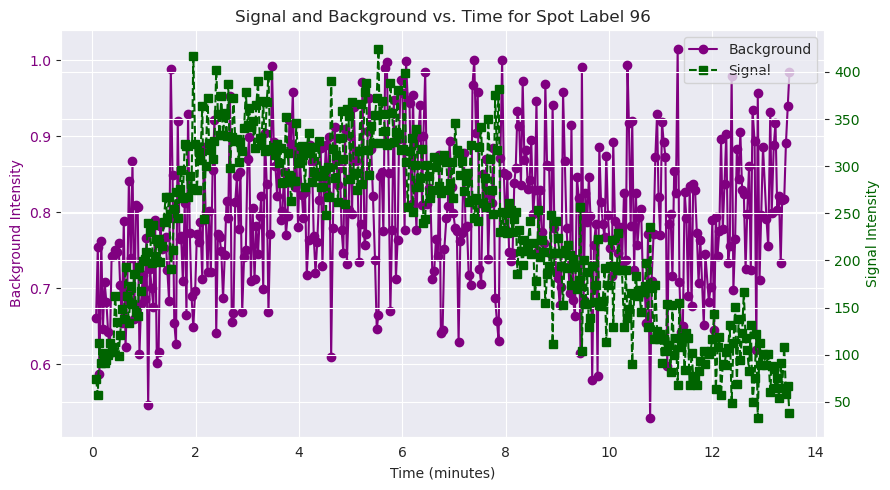

In [6]:
def plot_spot_trace(label_id):
    spot_trace = detected_spots[detected_spots["particle"] == label_id].sort_values("t_min")
    time = spot_trace["t_min"]
    signal = spot_trace["intensity_from_neighborhood"]
    background = spot_trace["background_intensity_from_neighborhood"]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(time, background, 'o-', color='purple', label='Background')
    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel("Background Intensity", color='purple')
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(time, signal, 's--', color='darkgreen', label='Signal')
    ax2.set_ylabel("Signal Intensity", color='darkgreen')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.set_facecolor('none')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.title(f"Signal and Background vs. Time for Spot Label {label_id}")
    fig.tight_layout()
    plt.show()
    plt.close()

# Example usage
plot_spot_trace(96)
